In [ ]:
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import numpy as np
import io
from pathlib import Path
import os
import h5py

# --- Path Configuration ---
# Uses pathlib to find the 'data' folder relative to this notebook
# Notebook is in: .../ROC_CI_pred/python_notebooks/old/
# We go up 2 levels (.parent.parent) to reach 'ROC_CI_pred', then into 'data'
current_dir = Path.cwd()
project_root = current_dir.parent.parent
ppath = project_root / "data"
saveFigPath = project_root / "plots"

# Create directories if they don't exist
saveFigPath.mkdir(parents=True, exist_ok=True)

# --- Colormap Configuration ---
# 1. Modern way to get discrete samples from existing maps
clist = []
for cname in ["winter", "spring"]:
    # Resample the colormap to 10 discrete steps directly
    clist.append(plt.get_cmap(cname).resampled(10))

# 2. Modern replacement for Parula
# 'viridis' is the standard Python equivalent to Parula (perceptually uniform).
# Use this instead of hardcoding 256 lines of data.
parula_map = plt.get_cmap('viridis') 

# --- Figure Parameters ---
FigParams = {
    "fig_size": 6,
    "font1": {"fontname": "Arial", "size": 32},
    "font2": {"fontname": "Arial", "size": 36},
    "line_w": 2,
    "colors_maps": clist,
    "colors_names": ["royalblue", "olivedrab", "darkorange", "firebrick"],
    "saveFigPath": str(saveFigPath),
    "ErrorBar": {
        'ErrDist': [0.4, 0.4],
        'ErrSize': 1,
        'ErrWid': 4,
        'sizedots': 10,
        'ErrColor': ["royalblue", "olivedrab", "darkorange", "firebrick"],
        'DotsColor': ["royalblue", "olivedrab", "darkorange", "firebrick"],
        'sizeMean': 25
    },
}

def packParams():
    return (
        FigParams["fig_size"],
        FigParams["font1"],
        FigParams["font2"],
        FigParams["line_w"],
        FigParams["colors_maps"],
        FigParams["colors_names"],
        FigParams["saveFigPath"],
    )

In [15]:
(figS, f_font1, f_font2, line_w, clist, colors_names, sp) = packParams()

In [16]:
def plot_tuning_heatmap(data_slice, title_suffix, tick_max=91, save_name=None):
    """
    Standardized plotter for the 2D tuning heatmaps.
    Uses globally defined 'figS', 'parula_map', 'f_font1' from your first cell.
    """
    fig, ax = plt.subplots(1, 1, figsize=(figS, figS))
    
    # Data is transposed to match original logic
    t = data_slice.T
    
    im = ax.imshow(t, cmap=parula_map)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)
    # Tick logic (Original: indices 0..l mapped to angle labels)
    l = data_slice.shape[0]
    ytck = [0, int(np.round(l/4)), int(np.round(l/2)), int(np.round(l*3/4)), l]
    # Explicit tick labels from your original code
    ytckL = [-70, 20, 110, 200, 290]
    ax.yaxis.set_ticks(ytck)
    ax.yaxis.set_ticklabels(ytckL, **f_font1)
    ax.xaxis.set_ticks(ytck)
    ax.xaxis.set_ticklabels(ytckL, **f_font1)
    
    # Original limits
    ax.set_xlim(-2, tick_max)
    ax.set_ylim(-2, tick_max)
    # Colorbar logic (matching original: only for the first file type)
    if title_suffix.startswith('VF'):
        cbar = plt.colorbar(im, ax=ax)
        dmin, dmax = np.min(t), np.max(t)
        # Dynamic ticks using data min/max/mid
        cbar.set_ticks([dmin, (dmin + dmax)/2, dmax])
        cbar.set_ticklabels(["0", "0.1", "0.2"]) 
        cbar.ax.tick_params(labelsize=38)
    if save_name:
        # 'sp' comes from packParams() -> saveFigPath
        plt.savefig(sp + save_name)
    
    plt.show()

Loading VF_full_subj2_ret keys: ['varfire']
Shape: (91, 91, 5, 5)


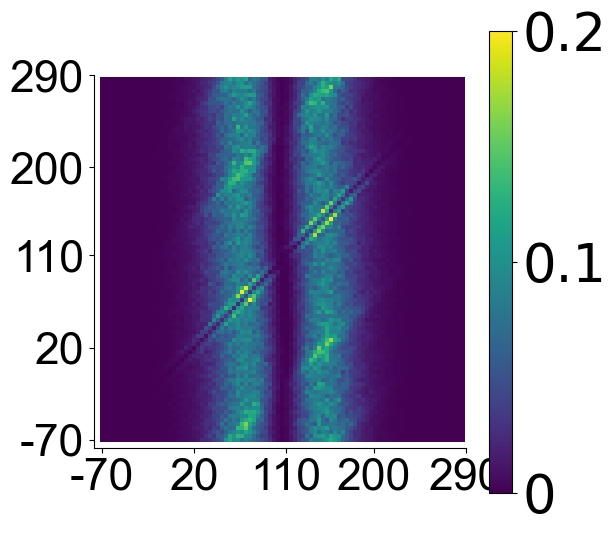

Loading VF_full_subj2_rel keys: ['varfire']
Shape: (91, 91, 5, 5)


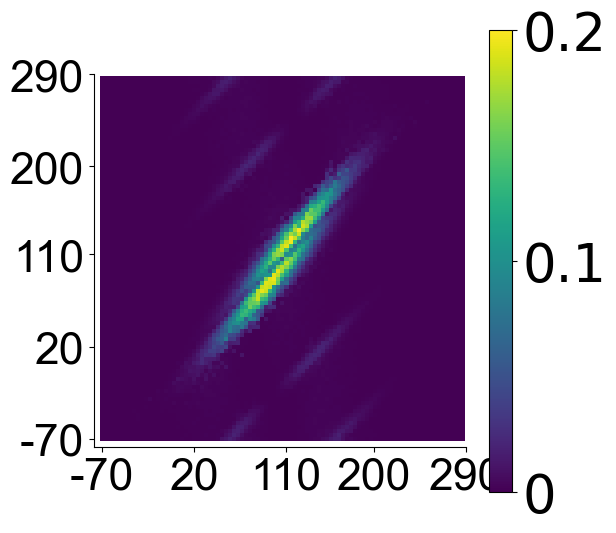

Loading meanFire.mat...


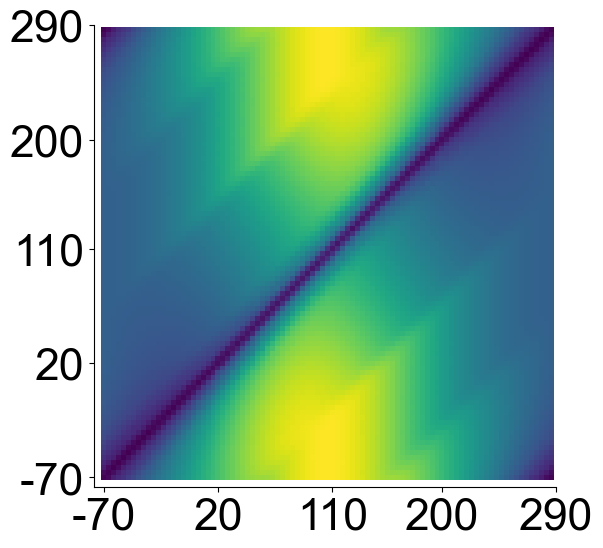

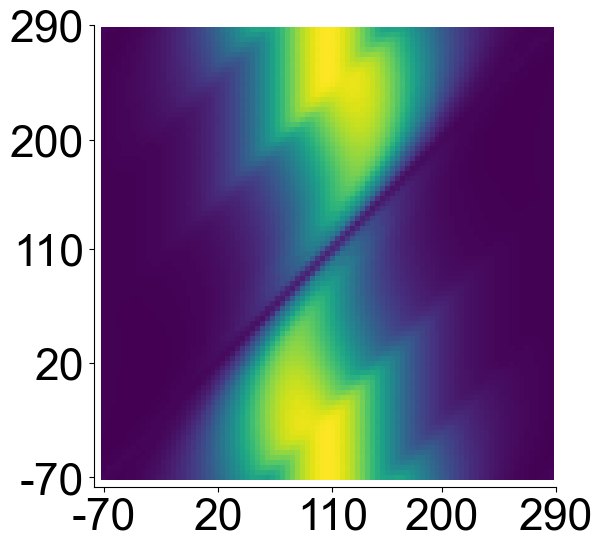

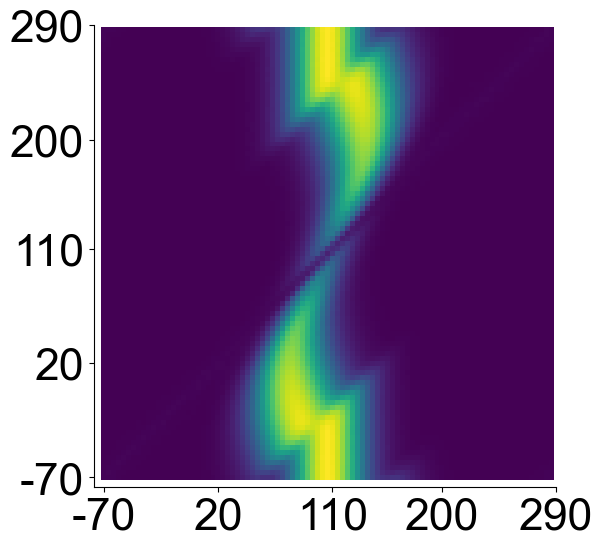

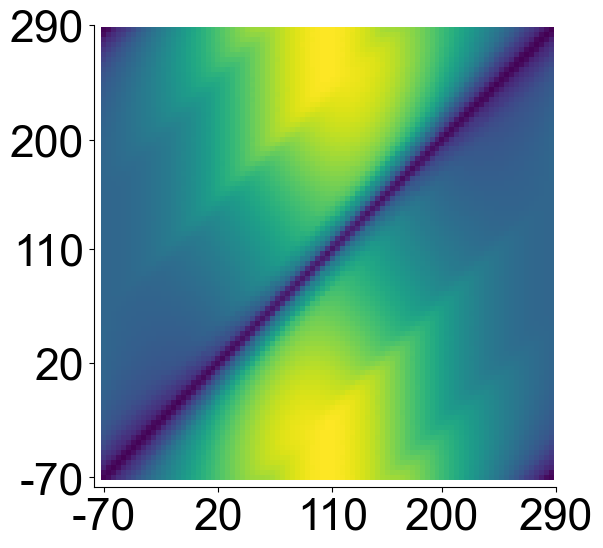

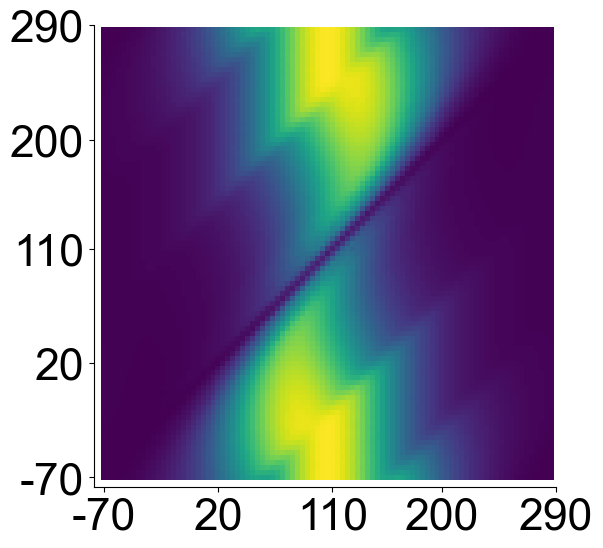

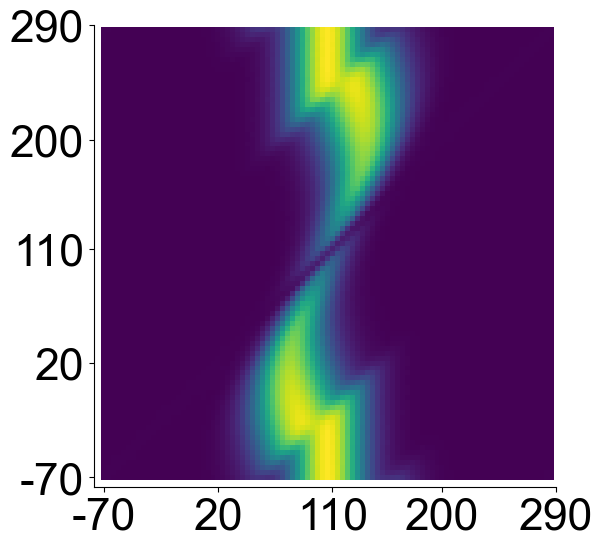

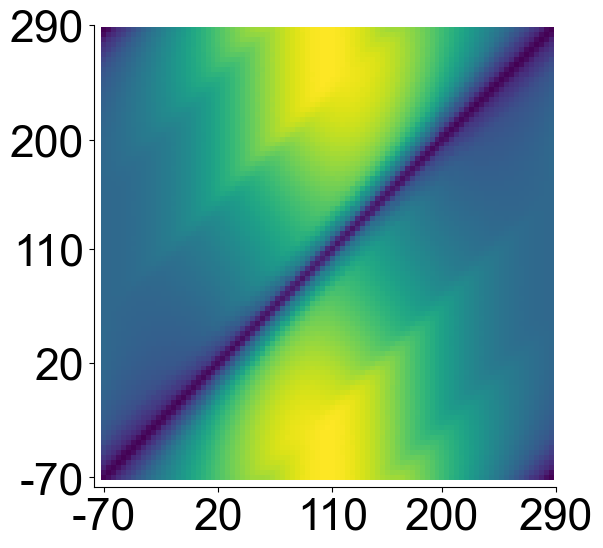

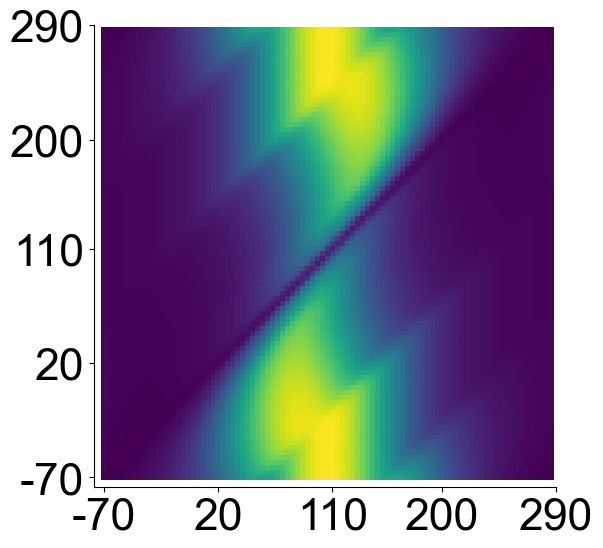

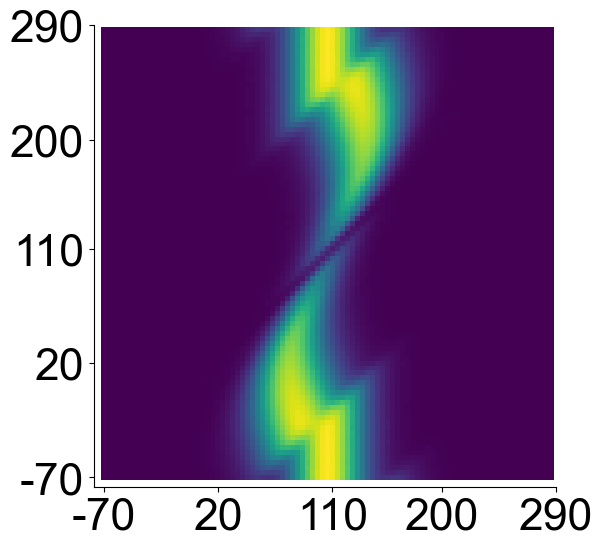

Loading neural_pred_subj_median_neuron_stim1_retVar.mat...


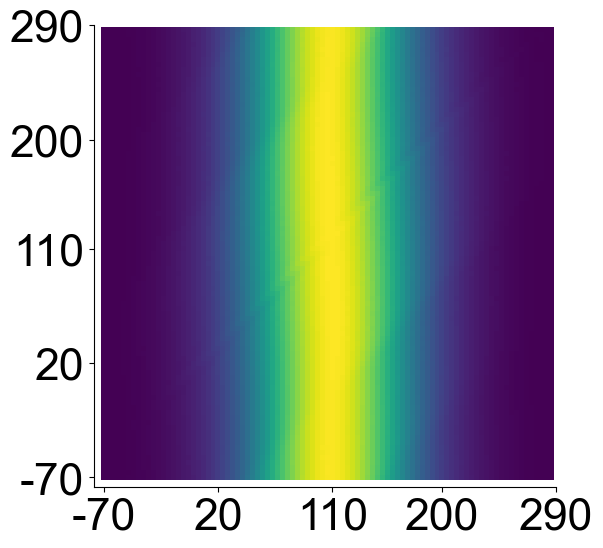

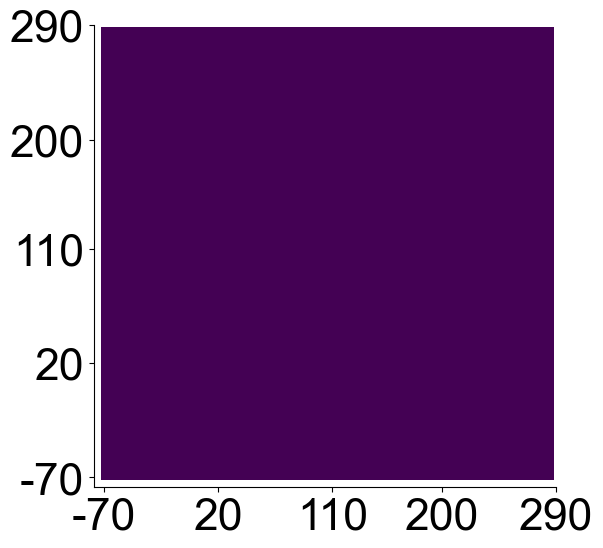

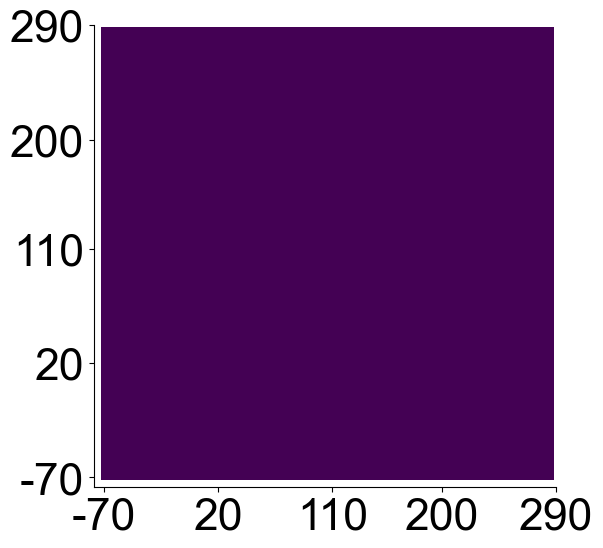

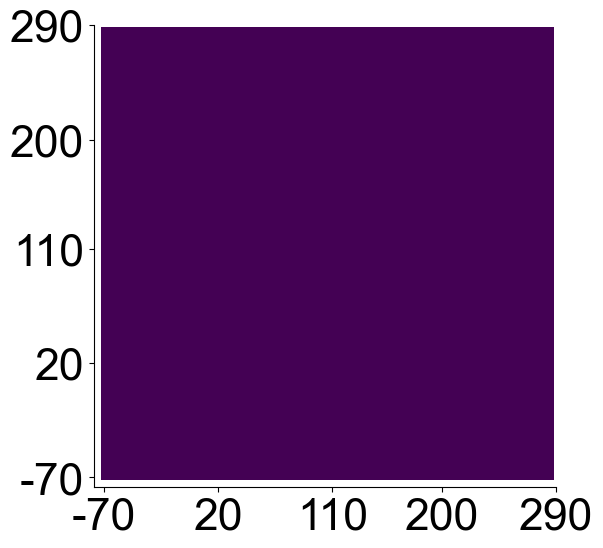

In [17]:
# --- 2. VF Data Loading & Plotting ---
vf_files = ['VF_full_subj2_ret', 'VF_full_subj2_rel']
for i, fname in enumerate(vf_files):
    fpath = ppath / (fname + '.mat')
    if not fpath.exists():
        print(f"Skipping {fname}: File not found at {fpath}")
        continue
        
    with h5py.File(fpath, 'r') as f:
        print(f"Loading {fname} keys: {list(f.keys())}")
        varfire = np.array(f['varfire'])
        
        # Specific slicing for the second file type 
        if i == 1 and varfire.ndim > 4:
             varfire = varfire[:,:,:,:,1]
        
        print(f"Shape: {varfire.shape}")
    # Plot
    plot_tuning_heatmap(
        varfire[:,:,2,2], 
        title_suffix=f'VF_{i}', 
        save_name=f'VF_full_subj2_{i}_refined.pdf'
    )
# --- 3. MeanFire Loading & Plotting ---
mf_path = ppath / 'meanFire.mat' 
if mf_path.exists():
    with h5py.File(mf_path, 'r') as f:
        print(f"Loading {mf_path.name}...")
        meanfire = np.array(f['meanfire'])
    
    # Loop Plotting (up to 9 as per original)
    n_plots = min(9, meanfire.shape[-1]) 
    for n in range(n_plots):
        # Slice: [:, :, 2, 2, 0, 1, n]
        data_slice = meanfire[:, :, 2, 2, 0, 1, n]
        plot_tuning_heatmap(data_slice, title_suffix=f'MeanFire_{n}')
else:
    print(f"Warning: {mf_path} not found.")
# --- 4. Neural Pred Subj Median ---
np_path = ppath / 'neural_pred_subj_median_neuron_stim1_retVar.mat'
if np_path.exists():
    with h5py.File(np_path, 'r') as f:
        print(f"Loading {np_path.name}...")
        # Key name was 'neural_pred_mu' in original
        neural_pred = np.array(f['neural_pred_mu']) 
        
    l = neural_pred.shape[0]
    df_shift = 3 # shift amount
    t_ = np.zeros((l, l))
    
    # Original looped range(4)
    for n in range(4):
        # Slice: [:, :, 2, 2, n, 1]
        data_raw = neural_pred[:, :, 2, 2, n, 1].T
        
        # Apply cyclic shift
        t_[:, 0:l-df_shift] = data_raw[:, df_shift:]
        t_[:, l-df_shift:]  = data_raw[:, 0:df_shift]
        
        # We pass the pre-transposed, shifted matrix. 
        # Helper transposes again, so we pass t_.T to cancel out helper's .T
        plot_tuning_heatmap(t_.T, title_suffix=f'NeuralPred_{n}')
else:
    print(f"Warning: {np_path} not found.")

# Example firing rates

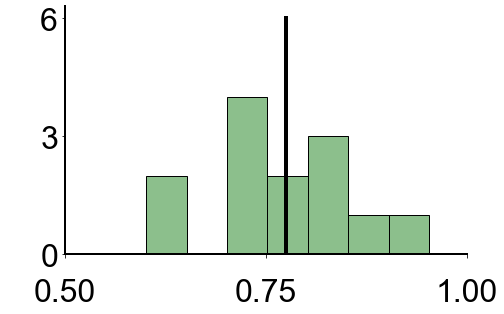

In [30]:
yy = np.array(Y_interp)
yy = yy[0]*yy[1]
for x1,x2 in zip([112,114,115,118,117,117,118,118,122], [3,3.15,3.2,3.3,3.4,3.1,3.15,3.12,3.15]):
        yy = np.append(yy, np.interp(x1, xd, r_dir)*np.interp(x2, xs, r_spd))
_, ax = plt.subplots(1, 1, figsize=(figS*1.2, figS*.76))
axins = ax
#axins.fill_between(X, Y-(error+error*Y), Y+(error+error*Y), color=c[1], alpha=0.4)
n, bins, patches = axins.hist(yy, bins=7, color="g", edgecolor="k", facecolor='none')
axins.plot([np.mean(yy), np.mean(yy)], [0,6], "-", color="k", linewidth=line_w+2)
# Set alpha for the face colors
for patch in patches:
    patch.set_facecolor((0.1, 0.5, 0.1, 0.5))  # RGBA where alpha = 0.5

axins.set_xlim([0.5,1.])
axins.yaxis.set_ticks([0,3,6])
axins.xaxis.set_ticks([0.5,0.75,1])
axins.spines["right"].set_visible(False)
axins.spines["top"].set_visible(False)
ax.spines["bottom"].set_linewidth(line_w)
ax.spines["left"].set_linewidth(line_w)
#axins.spines["bottom"].set_visible(False)
axins.grid(False)
axins.set_ylabel(" ", **f_font1)
axins.yaxis.set_ticklabels([0,3,6], **f_font1)
for labl in (axins.get_xticklabels()+axins.get_yticklabels()):
        labl.set_fontname(f_font1["fontname"])
        labl.set_fontsize(f_font1["size"])
axins.tick_params(axis='x', pad=20)
#plt.tight_layout()
#plt.savefig(sp+"TunC_example3_"+str(i)+".pdf")
plt.show()